# English League Dataset Cleaning

### Import Dataset

### **English League Datset Overview**

In [35]:
import pandas as pd

df = pd.read_csv("mydata.csv")

df.head()


,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
0,28th May 2023,4:30pm,Emirates Stadium,h,"60,095",2,5,13,0,51.0,...,52.2,0,3,8,11,0,0,0,0,https://www.skysports.com/football/arsenal-vs-...
1,28th May 2023,4:30pm,Villa Park,h,"42,212",7,2,6,1,40.3,...,47.8,3,3,15,16,4,4,0,0,https://www.skysports.com/football/aston-villa...
2,28th May 2023,4:30pm,Gtech Community Stadium,h,"17,120",9,1,1,0,34.4,...,50.0,2,3,12,8,4,0,0,0,https://www.skysports.com/football/brentford-v...
3,28th May 2023,4:30pm,Stamford Bridge,d,"40,130",12,1,4,1,64.4,...,45.5,3,5,9,11,0,0,0,0,https://www.skysports.com/football/chelsea-vs-...
4,28th May 2023,4:30pm,Selhurst Park,d,"25,198",11,1,16,1,66.0,...,41.7,3,2,9,13,0,2,0,0,https://www.skysports.com/football/crystal-pal...


### **Inspect the Data Structure**

In [36]:
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              1140 non-null   str    
 1   clock             1140 non-null   str    
 2   stadium           1140 non-null   str    
 3   class             1140 non-null   str    
 4   attendance        1140 non-null   str    
 5   Home Team         1140 non-null   int64  
 6   Goals Home        1140 non-null   int64  
 7   Away Team         1140 non-null   int64  
 8   Away Goals        1140 non-null   int64  
 9   home_possessions  1140 non-null   float64
 10  away_possessions  1140 non-null   float64
 11  home_shots        1140 non-null   int64  
 12  away_shots        1140 non-null   int64  
 13  home_on           1140 non-null   int64  
 14  away_on           1140 non-null   int64  
 15  home_off          1140 non-null   int64  
 16  away_off          1140 non-null   int64  
 17  home_b

### **Check for Duplicate Rows**

In [37]:
df.duplicated().sum()

np.int64(0)

### **Standardize the column names**

#### *Column names before standardization*

In [38]:
df.columns

Index(['date', 'clock', 'stadium', 'class', 'attendance', 'Home Team',
       'Goals Home', 'Away Team', 'Away Goals', 'home_possessions',
       'away_possessions', 'home_shots', 'away_shots', 'home_on', 'away_on',
       'home_off', 'away_off', 'home_blocked', 'away_blocked', 'home_pass',
       'away_pass', 'home_chances', 'away_chances', 'home_corners',
       'away_corners', 'home_offside', 'away_offside', 'home_tackles',
       'away_tackles', 'home_duels', 'away_duels', 'home_saves', 'away_saves',
       'home_fouls', 'away_fouls', 'home_yellow', 'away_yellow', 'home_red',
       'away_red', 'links'],
      dtype='str')

#### *Column names after standardization*

In [39]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['date', 'clock', 'stadium', 'class', 'attendance', 'home_team',
       'goals_home', 'away_team', 'away_goals', 'home_possessions',
       'away_possessions', 'home_shots', 'away_shots', 'home_on', 'away_on',
       'home_off', 'away_off', 'home_blocked', 'away_blocked', 'home_pass',
       'away_pass', 'home_chances', 'away_chances', 'home_corners',
       'away_corners', 'home_offside', 'away_offside', 'home_tackles',
       'away_tackles', 'home_duels', 'away_duels', 'home_saves', 'away_saves',
       'home_fouls', 'away_fouls', 'home_yellow', 'away_yellow', 'home_red',
       'away_red', 'links'],
      dtype='str')

### **Convert 'date' to datetime**

In [40]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# verify conversion
df['date'].dtype

dtype('<M8[us]')

#### *Extract Year*

In [41]:
df['year'] = df['date'].dt.year

#### *Extract Month*

In [42]:
df['month'] = df['date'].dt.month

#### *Extract Day*

In [43]:
df['day'] = df['date'].dt.day

#### *Create 'Season' Variable*

In [44]:
df['season'] = df['year'].astype(str) + "-" + (df['year'] + 1).astype(str)

##### Qucik verify of year, month,day,season columns

In [45]:
df[['date','year','month','day','season']].head()

,date,year,month,day,season
0,2023-05-28,2023.0,5.0,28.0,2023.0-2024.0
1,2023-05-28,2023.0,5.0,28.0,2023.0-2024.0
2,2023-05-28,2023.0,5.0,28.0,2023.0-2024.0
3,2023-05-28,2023.0,5.0,28.0,2023.0-2024.0
4,2023-05-28,2023.0,5.0,28.0,2023.0-2024.0


### **Clean 'attendance'**

In [46]:
df['attendance'] = df['attendance'].str.replace(',', '', regex=False)
df['attendance'] = pd.to_numeric(df['attendance'], errors='coerce')

# verify conversion
df['attendance'].dtype

dtype('int64')

### **Convert home_team and away_team from numerical to categorical** - ***LOGISTIC REGRESSION MODELING ONLY/ NOT NEEDED FOR RANDOM FOREST OR XGBOOST MODELING!***

In [47]:
df['home_team'] = df['home_team'].astype('category')
df['away_team'] = df['away_team'].astype('category')

#### *Then one-hot encode* (Only before modeling)

In [48]:
df = pd.get_dummies(df, columns=['home_team', 'away_team'], drop_first=True)

### **Drop the 'links' column**

In [49]:
df = df.drop(columns=['links'])

### **Inspect the class column**

In [50]:
df['class'].value_counts()

class
h    494
a    390
d    256
Name: count, dtype: int64

***Not sure if we want to keep this or drop the 'class' variable due to it containing match outcomes, and can thus lead to data leakage. We would need to drop home_goals and away_goals from predictors to prevent data leakage. Or we could drop class alltogether - Will leave this to the person the discretion of whoever is perfroming predictive modeling***

#### *Code to Drop Class if needed (Optional)*

In [51]:
df = df.drop(columns=['class'])

### **Final cleaning check**

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 88 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              580 non-null    datetime64[us]
 1   clock             1140 non-null   str           
 2   stadium           1140 non-null   str           
 3   attendance        1140 non-null   int64         
 4   goals_home        1140 non-null   int64         
 5   away_goals        1140 non-null   int64         
 6   home_possessions  1140 non-null   float64       
 7   away_possessions  1140 non-null   float64       
 8   home_shots        1140 non-null   int64         
 9   away_shots        1140 non-null   int64         
 10  home_on           1140 non-null   int64         
 11  away_on           1140 non-null   int64         
 12  home_off          1140 non-null   int64         
 13  away_off          1140 non-null   int64         
 14  home_blocked      1140 non-null   i

### **Create target variables (for predictive modeling)**

#### *Predicting match outcomes:* 'result' target variable

In [53]:
df['result'] = df.apply(
    lambda x: 'home_win' if x['goals_home'] > x['away_goals']
    else ('away_win' if x['goals_home'] < x['away_goals'] else 'draw'),
    axis=1
)

# Or encode:
df['result_encoded'] = df['result'].map({
    'home_win': 0,
    'draw': 1,
    'away_win': 2
})

#### *Tests home advantage:* Home_Win_Binary

In [54]:
df['home_win_binary'] = (df['goals_home'] > df['away_goals']).astype(int)

#### *Analyze away team performance:* Away_Win_Binary

In [55]:
df['away_win_binary'] = (df['away_goals'] > df['goals_home']).astype(int)

#### *Predict draws:* Draw_Binary

In [56]:
df['draw_binary'] = (df['goals_home'] == df['away_goals']).astype(int)

#### *Supports performance analysis:* Close_Match (Competitiveness)

In [57]:
df['close_match'] = (abs(df['goals_home'] - df['away_goals']) <= 1).astype(int)

### **Create Difference Feaures**

#### *Tests whether higher possesions lead to winning:* Possesion_Difference

In [58]:
df['possession_diff'] = df['home_possessions'] - df['away_possessions']

#### *Tests attacking performance:* Shots_Difference

In [59]:
df['shots_diff'] = df['home_shots'] - df['away_shots']

#### *Tests Shots on Target:* Shots_On_Target_Difference

In [60]:
df['shots_on_target_diff'] = df['home_on'] - df['away_on']

#### *Tests Fouls (Discipline):* Fouls_Difference

In [61]:
df['fouls_diff'] = df['home_fouls'] - df['away_fouls']

#### *Analyzes Discipline Impact:* Yellow_Difference, Red_Difference

In [62]:
df['yellow_diff'] = df['home_yellow'] - df['away_yellow']
df['red_diff'] = df['home_red'] - df['away_red']

#### *Tests if Higher Stadium Attendence Improves Home Performance:* Attendence_High, Attendence_Home_Advanatge 

In [63]:
df['attendance_high'] = (df['attendance'] > df['attendance'].median()).astype(int)

# OR also this which interacts with home wins:

df['attendance_home_advantage'] = df['attendance'] * df['home_win_binary']

#### *Analyzes Perfromance Strength:* Goal_Difference

In [64]:
df['goal_diff'] = df['goals_home'] - df['away_goals']

#### *Baseline Logistic Regression Model - Most Features*

Accuracy: 0.9823529411764705

Confusion Matrix:
 [[86  0]
 [ 3 81]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        86
           1       1.00      0.96      0.98        84

    accuracy                           0.98       170
   macro avg       0.98      0.98      0.98       170
weighted avg       0.98      0.98      0.98       170


Feature Importance:
                       Feature  Coefficient
90  attendance_home_advantage     4.351993
85       shots_on_target_diff     0.767494
23                 home_saves     0.702189
5                     home_on     0.681818
73               away_team_17     0.360455
..                        ...          ...
7                    home_off    -0.333106
14               away_chances    -0.499534
6                     away_on    -0.531571
82                close_match    -0.548819
24                 away_saves    -1.015695

[91 rows x 2 columns]
RMSE (Logistic Regr

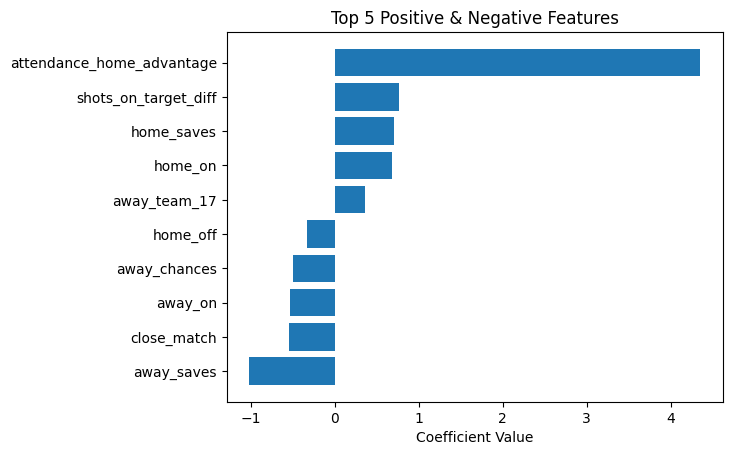

In [65]:
## Features to predict if home team wins. These are variables that describe how the match was played
exclude_cols = [
    'home_win_binary',   ## target
    'away_win_binary',
    'draw_binary',
    'result',
    'result_encoded',
    'goals_home',        ## direct leakage
    'away_goals',
    'goal_diff',         ## derived leakage
    'date',
    'clock',
    'stadium',
    'season'
]

X = df.drop(columns=exclude_cols, errors='ignore')

## keep only numeric + boolean columns
X = X.select_dtypes(include=['int64', 'float64', 'bool'])

## convert bool → int (for scaling)
X = X.astype(float)

y = df['home_win_binary']

## Train on older matches, Test on newer matches. More realworld prediction and model learns
## if games are different in different seasons.
train = df[df['year'] < 2023]
test = df[df['year'] >= 2023]

X_train = train[X.columns]
y_train = train['home_win_binary']

X_test = test[X.columns]
y_test = test['home_win_binary']

## There's variance in variable sizes.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model = LogisticRegression(max_iter=1000)
## Fitting the model to learn relationships like do more shots increase the chance to win?
model.fit(X_train_scaled, y_train)

##Predictions
y_pred = model.predict(X_test_scaled)

## Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Feature importance (coefficients)
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:\n", coef_df)

## Use Probabilities for RMSE comparison
y_prob = model.predict_proba(X_test_scaled)[:, 1]
rmse = np.sqrt(mean_squared_error(y_test, y_prob))

print("RMSE (Logistic Regression):", rmse)

## Get top 5 positive and bottom 5 negative
top_5 = coef_df.sort_values(by='Coefficient', ascending=False).head(5)
bottom_5 = coef_df.sort_values(by='Coefficient', ascending=True).head(5)

## Combine
plot_df = pd.concat([top_5, bottom_5])

## Sort for better visualization
plot_df = plot_df.sort_values(by='Coefficient')

## Plot
plt.figure()
plt.barh(plot_df['Feature'], plot_df['Coefficient'])
plt.xlabel("Coefficient Value")
plt.title("Top 5 Positive & Negative Features")
plt.show()

#### *Logistic Regression Model - Some features selected for realistic starting point*

In [66]:
## Features to predict if home team wins. These are variables that describe how the match was played
features = [
    'possession_diff', ## control of the game
    'shots_diff', ## overall attacking pressure
    'shots_on_target_diff', ## how many good chances the team had.
    'fouls_diff', ## discipline - can hurt performance
    'yellow_diff', ## discipline
    'red_diff', ## discipline
    'attendance',  ## crowd size (possible home field advantage?)
    'attendance_high', ## big crowd vs smaller crowd
    'year' ## Captures changes over time 
]

X = df[features]
y = df['home_win_binary']

## Train on older matches, Test on newer matches. More realworld prediction and model learns
## if games are different in different seasons.
train = df[df['year'] < 2023]
test = df[df['year'] >= 2023]

X_train = train[features]
y_train = train['home_win_binary']

X_test = test[features]
y_test = test['home_win_binary']

## There's variance in variable sizes. 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
## Fitting the model to learn relationships like do more shots increase the chance to win?
model.fit(X_train_scaled, y_train)

##Predictions
y_pred = model.predict(X_test_scaled)

## Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Feature importance (coefficients)
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:\n", coef_df)

Accuracy: 0.6823529411764706

Confusion Matrix:
 [[57 29]
 [25 59]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.66      0.68        86
           1       0.67      0.70      0.69        84

    accuracy                           0.68       170
   macro avg       0.68      0.68      0.68       170
weighted avg       0.68      0.68      0.68       170


Feature Importance:
                 Feature  Coefficient
2  shots_on_target_diff     1.607366
6            attendance     0.396663
7       attendance_high     0.066896
8                  year     0.064037
4           yellow_diff     0.057065
3            fouls_diff    -0.054008
1            shots_diff    -0.207551
5              red_diff    -0.237226
0       possession_diff    -0.316028


#### *Baseline Gradient Boosting Model - Most Features*

Accuracy: 1.0

Confusion Matrix:
 [[86  0]
 [ 0 84]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        86
           1       1.00      1.00      1.00        84

    accuracy                           1.00       170
   macro avg       1.00      1.00      1.00       170
weighted avg       1.00      1.00      1.00       170


Feature Importance:
                       Feature    Importance
90  attendance_home_advantage  1.000000e+00
84                 shots_diff  1.268000e-15
20               away_tackles  9.831531e-16
83            possession_diff  3.359170e-16
22                 away_duels  1.732441e-16
..                        ...           ...
32                      month  0.000000e+00
31                       year  0.000000e+00
30                   away_red  0.000000e+00
45               home_team_13  0.000000e+00
11                  home_pass -2.540131e-17

[91 rows x 2 columns]
RMSE (Gradient Boostin

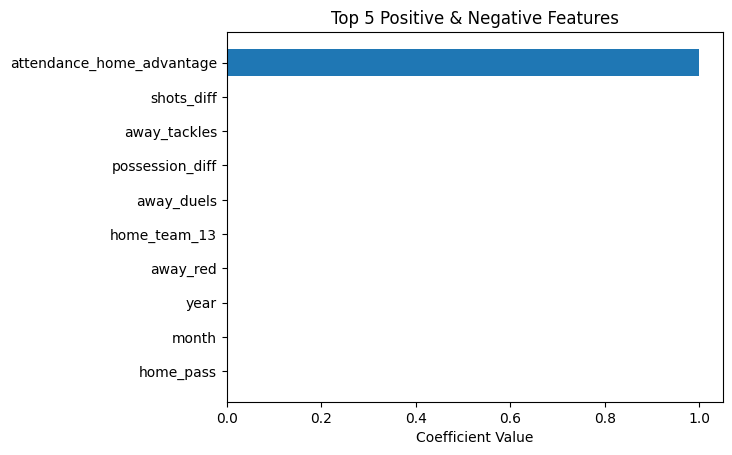

In [67]:
## Features to predict if home team wins. These are variables that describe how the match was played
exclude_cols = [
    'home_win_binary',   ## target
    'away_win_binary',
    'draw_binary',
    'result',
    'result_encoded',
    'goals_home',        ## direct leakage
    'away_goals',
    'goal_diff',         ## derived leakage
    'date',
    'clock',
    'stadium',
    'season'
]

X = df.drop(columns=exclude_cols, errors='ignore')

## keep only numeric + boolean columns
X = X.select_dtypes(include=['int64', 'float64', 'bool'])

## convert bool → int (for scaling)
X = X.astype(float)

y = df['home_win_binary']

## Train on older matches, Test on newer matches. More realworld prediction and model learns
## if games are different in different seasons.
train = df[df['year'] < 2023]
test = df[df['year'] >= 2023]

X_train = train[X.columns]
y_train = train['home_win_binary']

X_test = test[X.columns]
y_test = test['home_win_binary']

## There's variance in variable sizes.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error
import numpy as np

model = GradientBoostingClassifier()
## Fitting the model to learn relationships like do more shots increase the chance to win?
model.fit(X_train_scaled, y_train)

##Predictions
y_pred = model.predict(X_test_scaled)

## Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Feature importance (coefficients)
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", coef_df)

## Use Probabilities for RMSE comparison
y_prob = model.predict_proba(X_test_scaled)[:, 1]
rmse = np.sqrt(mean_squared_error(y_test, y_prob))

print("RMSE (Gradient Boosting):", rmse)

## Get top 5 positive and bottom 5 negative
top_5 = coef_df.head(5)
bottom_5 = coef_df.tail(5)

## Sort for better visualization
plot_df = pd.concat([top_5, bottom_5]).sort_values(by='Importance')

## Plot
plt.figure()
plt.barh(plot_df['Feature'], plot_df['Importance'])
plt.xlabel("Coefficient Value")
plt.title("Top 5 Positive & Negative Features")
plt.show()

#### *Gradient Boosting Model - Some selected features for realistic starting point*

In [68]:
features = [
    'possession_diff',
    'shots_diff',
    'shots_on_target_diff',
    'fouls_diff',
    'yellow_diff',
    'red_diff',
    'attendance',
    'attendance_high',
    'year'
]

X = df[features]
y = df['home_win_binary']

train = df[df['year'] < 2023]
test = df[df['year'] >= 2023]

X_train = train[features]
y_train = train['home_win_binary']

X_test = test[features]
y_test = test['home_win_binary']

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

import pandas as pd

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance_df)

Accuracy: 0.6882352941176471

Confusion Matrix:
 [[63 23]
 [30 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70        86
           1       0.70      0.64      0.67        84

    accuracy                           0.69       170
   macro avg       0.69      0.69      0.69       170
weighted avg       0.69      0.69      0.69       170


Feature Importance:
                 Feature  Importance
2  shots_on_target_diff    0.424400
6            attendance    0.244240
0       possession_diff    0.141770
1            shots_diff    0.071806
4           yellow_diff    0.047251
3            fouls_diff    0.044662
5              red_diff    0.019970
8                  year    0.005086
7       attendance_high    0.000814
